In [3]:
# ============================================================
# Notebook setup: run this before everything
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(15, 4.5)

from util import util
import numpy as np
from sklearn.mixture import GaussianMixture

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Gaussian Mixture Models

## A Deeper Analysis

**We'll start by focusing on the scalability issues**

We have established that KDE has trouble with:

* Large dimensional datasets
* Large number of training examples

> **Can you make a guess about the root of the problem?**

**KDE makes no attempt to "compress" the information from the training data:**

* The size of a KDE models grows directly with the training set size
* In statistical terms, KDE has [very little bias and a very large variance](https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff)

It's time to introduce a new density estimation technique

## Gaussian Mixture Models

**In particular, we'll now switch to using _Gaussian Mixture Models (GMMs)_**

A GMM describes a distribution via a _weighted sum of Gaussian components_

<center><img src="assets/gmm_example.png" width=65%/></center>

## Gaussian Mixture Models

**In particular, we'll now switch to using _Gaussian Mixture Models (GMMs)_**

A GMM describes a distribution via a _weighted sum of Gaussian components_.

1. **Weighted Sum of Gaussian Components:**
   - A GMM models the data as a combination of multiple Gaussian distributions (also called components).
   - Each component has its own mean ($\mu_k$), covariance matrix ($\Sigma_k$), and weight ($\tau_k$).
   - The weights $\tau_k$ represent the probability of selecting each component and satisfy $\sum_{k=1}^n \tau_k = 1$.

   **Example:**
   Suppose we have two Gaussian components:
   - Component 1: $\mu_1 = 0$, $\sigma_1 = 1$, $\tau_1 = 0.6$
   - Component 2: $\mu_2 = 5$, $\sigma_2 = 2$, $\tau_2 = 0.4$

   The GMM combines these two components into a single distribution. **A data point is generated by first selecting a component (e.g., Component 1 with 60% probability) and then sampling from the corresponding Gaussian distribution.**

2. **Random Variables:**
   - $Z$: A random variable that represents the index of the Gaussian component that generates a given data point. For example, if there are 3 components, $Z$ can take values 1, 2, or 3.
   - $X_k$: A random variable that represents the data generated by the $k$-th Gaussian component. Each $X_k$ follows a **multivariate Gaussian distribution.** A multivariate Gaussian distribution is a generalization of the one-dimensional Gaussian distribution to higher dimensions, characterized by a mean vector and a covariance matrix. Basically, it describes how the data is distributed in a multi-dimensional space in a guassian-like manner.

   **Example:**
   - If $Z = 1$, the data point is sampled from the first Gaussian component $X_1 \sim \mathcal{N}(\mu_1, \Sigma_1)$.
   - If $Z = 2$, the data point is sampled from the second Gaussian component $X_2 \sim \mathcal{N}(\mu_2, \Sigma_2)$.

3. **Bias-Variance Trade-off:**
   - The number of components in a GMM affects the bias-variance trade-off.
   - A small number of components may lead to high bias (the model is too simple to capture the data).
   - A large number of components may lead to high variance (the model overfits the data).

   **Example:**
   - If we use only 1 component to model a dataset with two distinct clusters, the model will have high bias and fail to capture the structure of the data.
   - If we use 10 components for the same dataset, the model may overfit and create unnecessary complexity.

### Formal Definition

**Formally, we assume data is generated by the following probabilistic model:**

$$
X \sim \sum_{k=1}^n \tau_k \mathcal{N}(\mu_k, \Sigma_k)
$$

- $X$ is the observed data.
- $\mathcal{N}(\mu_k, \Sigma_k)$ is the Gaussian distribution for the $k$-th component.
- $\tau_k$ is the weight of the $k$-th component.

**In other words, a GMM is _a selection-based ensemble_** where each data point is generated by first selecting a component and then sampling from its Gaussian distribution.

**Formally, we assume data is generated by the following probabilistic model**

$$
X_Z
$$

* $Z$ e $X_k$ are both random variables
* $Z$ represents the index of the component that generates the sample
* $X_k$ follows a multivariate Gaussian distribution

In other words, a GMM is _a selection-based ensemble_

## A GMM Example

**Let's build a (random) GMM in two dimensions so see an example**

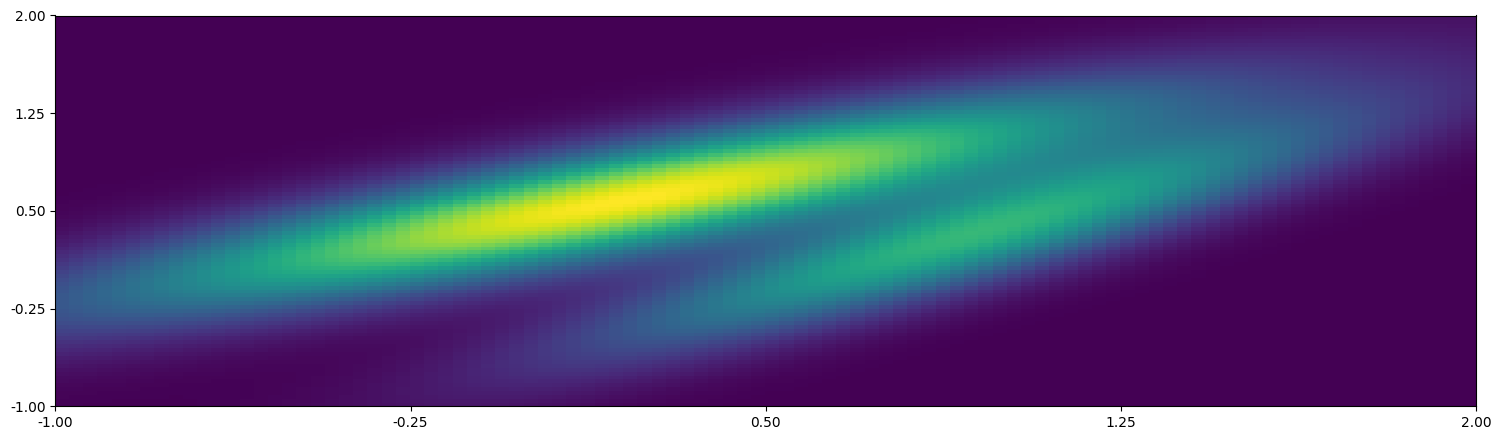

In [4]:
gt = util.generate_gmm_dist(n_components=2, seed=59)
util.plot_density_estimator_2D(gt, xr=np.linspace(-1, 2, 100), yr=np.linspace(-1, 2, 100), figsize=figsize)

* Our example has two components, each with its own mean and covariance
* One component is slightly less prevalent than the other

## GMM Parameters

**The PDF of a GMM is given by:**

$$
g(x, \mu, \Sigma, \tau) = \sum_{k = 1}^{n} \tau_k f(x, \mu_k, \Sigma_k)
$$

* $f$ is the PDF of a multivariante Normal distribution
* $\mu_k$ is the (vector) mean and $\Sigma_k$ the covariance matrix for the $k$-th component
* $\tau_k$ corresponds to $P(Z = k)$

**We can inspect the values for our example GMM**

In [5]:
print('tau:', gt.weights)
print('mu', str(gt.mu).replace('\n', ' '))
print('sigma', str(gt.sigma).replace('\n', ' '))

tau: [0.69756198 0.30243802]
mu [[0.20612642 0.58696692]  [0.94152811 0.3112852 ]]
sigma [array([[0.5610369 , 0.3646768 ],        [0.3646768 , 0.31593376]]), array([[0.29862754, 0.29550211],        [0.29550211, 0.35832187]])]


## Sampling from GMMs

**When we want to _sample_ from a GMM**

* First we need to sample the $Z$ variable
* Then we sample from the corresponding multivariate distribution

In [ ]:
train_x, train_z = gt.sample(1000, seed=42) #train_x contains the data points, train_z contains the component index for each data point
test_x, test_z = gt.sample(1000, seed=42)

**Hence, we don't get to now just the sample value**

...But also _which of the Gaussian components_ it was generated by

In [7]:
print('z values :', train_z[:4])
print('x values:', train_x[:4])

z values : [0 1 1 0]
x values: [[ 0.25595526  0.24144331]
 [ 0.65952904  0.16087875]
 [ 0.50240258  0.11145718]
 [-0.47036887  0.2317656 ]]


## Training a Gaussian Mixture Model (GMM)

The goal of training a GMM is to approximate the distribution of a dataset using a combination of Gaussian components. Each component is a multivariate Gaussian distribution, and the GMM combines them using weights.

### The Training Objective

The training process involves finding the parameters of the GMM: 
- **Means ($\mu_k$):** Centers of the Gaussian components.
- **Covariance matrices ($\Sigma_k$):** Spread and orientation of each Gaussian component.
- **Weights ($\tau_k$):** Probabilities of selecting each component, satisfying $\sum_{k=1}^n \tau_k = 1$.

The objective is to maximize the **likelihood function ($L$)**, which measures how likely the observed data is under the GMM:

$$
\mathop{\arg\max}_{\mu, \Sigma, \tau}\ \mathbb{E}_{x \sim X}\left[ L(x, \mu, \Sigma, \tau) \right]
$$

This can be approximated using the training set:

$$
\mathbb{E}_{x \sim X} \left[ L(x, \mu, \Sigma, \tau)\right] \simeq \prod_{i = 1}^m g(x_i, \mu, \Sigma, \tau)
$$

Here:
- $g(x, \mu, \Sigma, \tau) = \sum_{k=1}^n \tau_k f(x, \mu_k, \Sigma_k)$ is the GMM's probability density function (PDF).
- $f(x, \mu_k, \Sigma_k)$ is the PDF of the $k$-th Gaussian component.

This approach is an example of **Monte Carlo estimation**, where the expectation is approximated using the training data.

**Let's put everything together**

$$\begin{align}
\mathop{\arg\max}_{\mu, \Sigma, \tau}\ & \prod_{i = 1}^m \sum_{k = 1}^{n} \tau_k f(x, \mu_k, \Sigma_k) \\
\text{s.t. } & \sum_{k=1}^n \tau_k = 1
\end{align}$$


### Challenges in Optimization

The optimization problem is complex because:
1. There is a **constraint**: $\sum_{k=1}^n \tau_k = 1$.
2. The objective involves both a **product and a sum**, making it hard to optimize directly.

### Introducing Latent Variables

To simplify the problem, we introduce a **latent variable** $Z_i$ for each data point $x_i$. 
- $Z_i = k$ if $x_i$ was generated by the $k$-th Gaussian component.
- $Z_i$ is **latent** because we do not know its value.

Using $Z_i$, we can rewrite the GMM PDF as:

$$
\tilde{g}_i(x_i, z_i, \mu, \Sigma, \tau) = \tau_{z_i} f(x, \mu_{z_i}, \Sigma_{z_i})
$$

Here, $z_i$ is treated as an input, allowing us to avoid the summation over components. However, this introduces uncertainty over both $X$ (the data) and $Z_i$ (the latent variables).

### Reformulating the Problem

To handle the uncertainty over $Z_i$, we introduce new variables $\tilde{\tau}_{i,k}$, which represent the probability that $Z_i = k$ (i.e., the probability that $x_i$ belongs to the $k$-th component). These are estimated during training.

The expectation can now be computed in closed form:

$$
\mathbb{E}_{x \sim X, \{z_i\} \sim \{Z_i\}} \left[ L(x, z, \mu, \Sigma, \tau)\right] \simeq
\prod_{i=1}^m \prod_{k=1}^n \tilde{g}_i(x_i, z_i, \mu, \Sigma, \tau)^{\tilde{\tau}_{i,k}}
$$

**Why is $\tilde{\tau}_{i,k}$ in the exponent?**

The exponent $\tilde{\tau}_{i,k}$ represents the **weighted contribution** of each component to the likelihood:

- If we knew the latent variable $Z_i$ exactly (i.e., we sampled it), we would multiply the likelihood of the corresponding component once: $\tilde{g}_i(x_i, z_i, \mu, \Sigma, \tau)^1$.
- Since $Z_i$ is uncertain, we don't know which component generated $x_i$. Instead, $\tilde{\tau}_{i,k} = P(Z_i = k | x_i, \mu, \Sigma, \tau)$ tells us the **probability** that component $k$ generated $x_i$.
- The exponent $\tilde{\tau}_{i,k}$ weights the likelihood contribution of component $k$ by this probability. If component $k$ is likely to have generated $x_i$, its contribution is emphasized (higher exponent). If it's unlikely, its contribution is diminished (lower exponent).

This is equivalent to averaging over all possible assignments of $x_i$ to components, weighted by their probabilities—a key step in the **expectation** part of the EM algorithm.

This reformulation simplifies the optimization problem by removing the sum-product combination.

**The reworked training problem therefore is**

$$\begin{align}
\mathop{\arg\max}_{\mu, \Sigma, \tau, \tilde{\tau}}\ & \prod_{i=1}^m \prod_{k=1}^n \tilde{g}_i(x_i, z_i, \mu, \Sigma, \tau)^{\tilde{\tau}_{i,k}} \\
\text{s.t. } & \sum_{k=1}^n \tau_k = 1 \\
 & \sum_{k=1}^n \tilde{\tau}_{i,k} = 1 \quad\quad \forall i = 1..m
\end{align}$$

### The Expectation-Maximization (EM) Algorithm

The **EM algorithm** is used to solve the reworked optimization problem. It alternates between two steps:

1. **Expectation (E-step):**
   - Fix $\mu, \Sigma, \tau$ and estimate $\tilde{\tau}_{i,k}$, the probability that $x_i$ belongs to the $k$-th component.
   - This step computes the expectation over the latent variables $Z$.

2. **Maximization (M-step):**
   - Fix $\tilde{\tau}_{i,k}$ and update $\mu, \Sigma, \tau$ to maximize the likelihood. What do we mean by 'likelihood'? We mean that we want the GMM with parameters that best explain the observed data. We want the PDF as high as possible for the training data.

The E-step estimates the probabilities $\tilde{\tau}_{i,k}$ = P($Z_i = k$ | $x_i$, $\mu$, $\Sigma$, $\tau$), which represents the likelihood that data point $x_i$ was generated by component $k$ given the current parameters. These probabilities are then used in the M-step to update the parameters of the GMM.

This process is repeated until the parameters converge to a **local optimum**.



### Why Use GMMs?

GMMs are powerful because they can:
- Model complex, multi-modal distributions.
- Provide additional information, such as the probability of a data point belonging to each component.
- Perform clustering by assigning data points to components based on maximum probability.

In high-dimensional spaces, GMMs are particularly useful because they can model relationships between features (via the covariance matrix) and handle complex data distributions that simpler models like k-means cannot.

## GMM in Action

**There are many implementations and variants of the EM method**

We will use the code from scikit-learn:

In [8]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=2, random_state=4)
gm.fit(train_x);

* The API is the usual one

**We need to specify the number of components a priori**

* We can tune it using a maximum likelihood approach on a validation set
* ...Or using other criteria (e.g. elbow method)  

## Inspecting the Results

**Let's inspect the learned parameters**

In [9]:
print('Learned weights', gm.weights_)
print('True weights', gt.weights)

Learned weights [0.6590098 0.3409902]
True weights [0.69756198 0.30243802]


In [10]:
print('Learned means', str(gm.means_).replace('\n', ' '))
print('True means', str(gt.mu).replace('\n', ' '))

Learned means [[0.06974974 0.54625223]  [0.96907679 0.40083217]]
True means [[0.20612642 0.58696692]  [0.94152811 0.3112852 ]]


In [11]:
print('Learned covariance #1', str(gm.covariances_[0]).replace('\n', ' '))
print('True covariance #1', str(gt.sigma[0]).replace('\n', ' '))
print('Learned covariance #2', str(gm.covariances_[1]).replace('\n', ' '))
print('True covariance #2', str(gt.sigma[1]).replace('\n', ' '))

Learned covariance #1 [[0.47861885 0.32101492]  [0.32101492 0.28622476]]
True covariance #1 [[0.5610369  0.3646768 ]  [0.3646768  0.31593376]]
Learned covariance #2 [[0.26613038 0.26083955]  [0.26083955 0.34615556]]
True covariance #2 [[0.29862754 0.29550211]  [0.29550211 0.35832187]]


## Inspecting the Results

**Here is the approximated PDF**

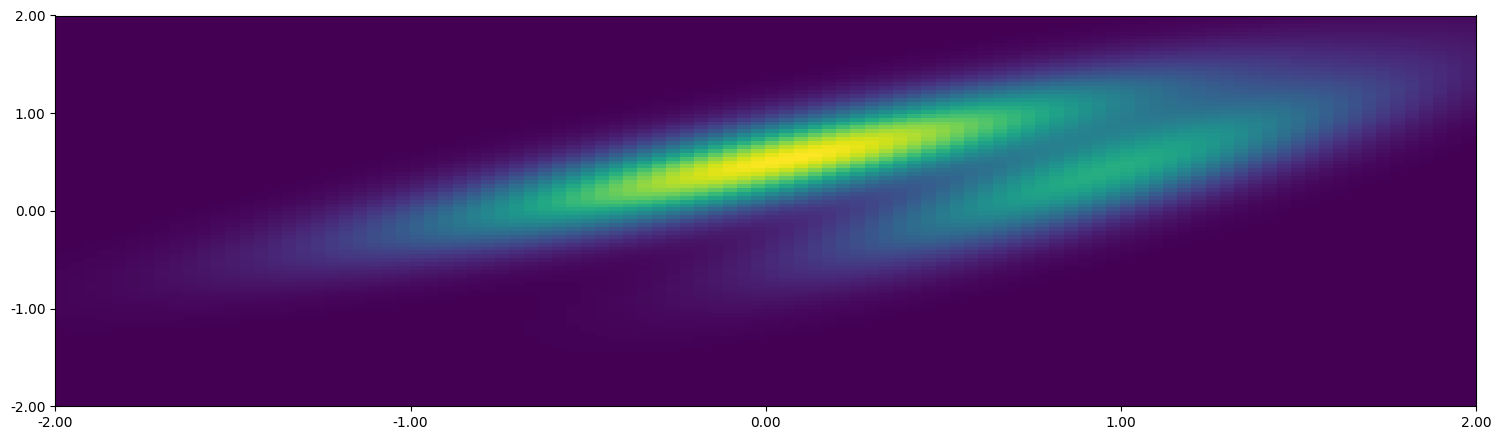

In [12]:
util.plot_density_estimator_2D(gm, xr=np.linspace(-2, 2, 100), yr=np.linspace(-2, 2, 100), figsize=figsize)

## Which Kind of Prediction

**GMMs are very flexible in terms of what they can do**

We can use them to _evaluate the (log) density_ of a sample:

In [13]:
pred_lf = np.exp(gm.score_samples(train_x))
print('Log densities:', pred_lf[:3])

Log densities: [0.17629181 0.29102933 0.21023248]


We can use them to _generate a sample_:

In [14]:
pred_x, pred_z = gm.sample(3)
print('Sampled values:', str(pred_x).replace('\n', ' '))
print('Sampled components:', pred_z)

Sampled values: [[ 0.74060004  0.14883754]  [ 0.31220378 -0.02384664]  [ 0.30811268 -0.47618621]]
Sampled components: [1 1 1]


## More then Densities

**GMMs are very flexible in terms of what they can do**

We can estimate the _probability that a sample belongs to a component_.
This is done by evaluating the posterior distribution P($Z = k$ | $X = x$) using Bayes' theorem: $P(Z = k | X = x) = \frac{P(X = x | Z = k) P(Z = k)}{P(X = x)}$
We know that $P(X = x | Z = k)$ is given by the Gaussian PDF of component $k$, $P(Z = k)$ is given by the weight $\tau_k$, and $P(X = x)$ is given by the GMM PDF evaluated at $x$.

In [15]:
pred_p = gm.predict_proba(train_x)
print('Probability of belonging to a component:')
print(pred_p[:3])

Probability of belonging to a component:
[[0.84724085 0.15275915]
 [0.01845649 0.98154351]
 [0.05474391 0.94525609]]


* The approach is the same we used to optimize $\tilde{\tau}_{i,k}$ in the expectation step

By picking the maximum probability, we can _assign samples to a component_ 

In [16]:
pred_c = gm.predict(train_x)
print(pred_c[:3])

[0 1 1]


## More then Densities

**GMMs can certainly act as density estimators**

...But can do much more!

* Sampling
* Component assignment
* ...And therefore _clustering_

This is so true that GMM are often presented as a generalization of k-means

**And this (partially) addresses the last limitation of KDE**

* By choosing certain density estimator
* ...We can obtain additional information in addition to the densities